In [71]:
# Download Packages
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import annoy

from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sb
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sc.set_figure_params(figsize=(5,5)) # no blurry figures allowed

In [72]:
# Load Multiome Data

# CR OUTPUT #

dr = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/cr_arc_outputs/'

nk_sfd = sc.read_10x_h5(dr + 'NK_1-SFD/outs/filtered_feature_bc_matrix.h5', gex_only=False)
nk_hfd = sc.read_10x_h5(dr + 'NK_2-HFD/outs/filtered_feature_bc_matrix.h5', gex_only=False)
nk_glp = sc.read_10x_h5(dr + 'NK_3-HFD_GLP/outs/filtered_feature_bc_matrix.h5', gex_only=False)
nk_cr  = sc.read_10x_h5(dr + 'NK_4-HFD_CR/outs/filtered_feature_bc_matrix.h5', gex_only=False)

In [73]:
# Investigating Structure of Data
for name, adata in [('NK_SFD', nk_sfd), ('NK_HFD', nk_hfd), ('NK_GLP', nk_glp), ('NK_CR', nk_cr)]:
    print(f"\n--- {name} ---")
    print(adata)
    print(Counter(adata.var['feature_types']))
    print(adata.var.iloc[:3, :5].to_string())
    print("\nExpression matrix (5 cells x 5 genes):")
    gex = adata[:, adata.var['feature_types'] == 'Gene Expression'].copy()
    gex.var_names_make_unique()
    print(pd.DataFrame(
        gex.X[:5, :5].toarray(),
        index=gex.obs_names[:5],
        columns=gex.var_names[:5]
    ).to_string())


--- NK_SFD ---
AnnData object with n_obs × n_vars = 4641 × 113467
    var: 'gene_ids', 'feature_types', 'genome', 'interval'
Counter({'Peaks': 81182, 'Gene Expression': 32285})
                   gene_ids    feature_types genome              interval
Xkr4     ENSMUSG00000051951  Gene Expression   mm10  chr1:3671497-3671498
Gm1992   ENSMUSG00000089699  Gene Expression   mm10  chr1:3466586-3466587
Gm19938  ENSMUSG00000102331  Gene Expression   mm10  chr1:3658903-3658904

Expression matrix (5 cells x 5 genes):
                    Xkr4  Gm1992  Gm19938  Gm37381  Rp1
AAACAGCCACCTAAGC-1   0.0     0.0      0.0      0.0  0.0
AAACAGCCAGATTCAT-1   0.0     0.0      0.0      0.0  0.0
AAACAGCCATGAATCT-1   0.0     0.0      0.0      0.0  0.0
AAACATGCAAGGCCAA-1   0.0     0.0      0.0      0.0  0.0
AAACATGCACAACAAA-1   0.0     0.0      0.0      0.0  0.0

--- NK_HFD ---
AnnData object with n_obs × n_vars = 5637 × 117997
    var: 'gene_ids', 'feature_types', 'genome', 'interval'
Counter({'Peaks': 85712,

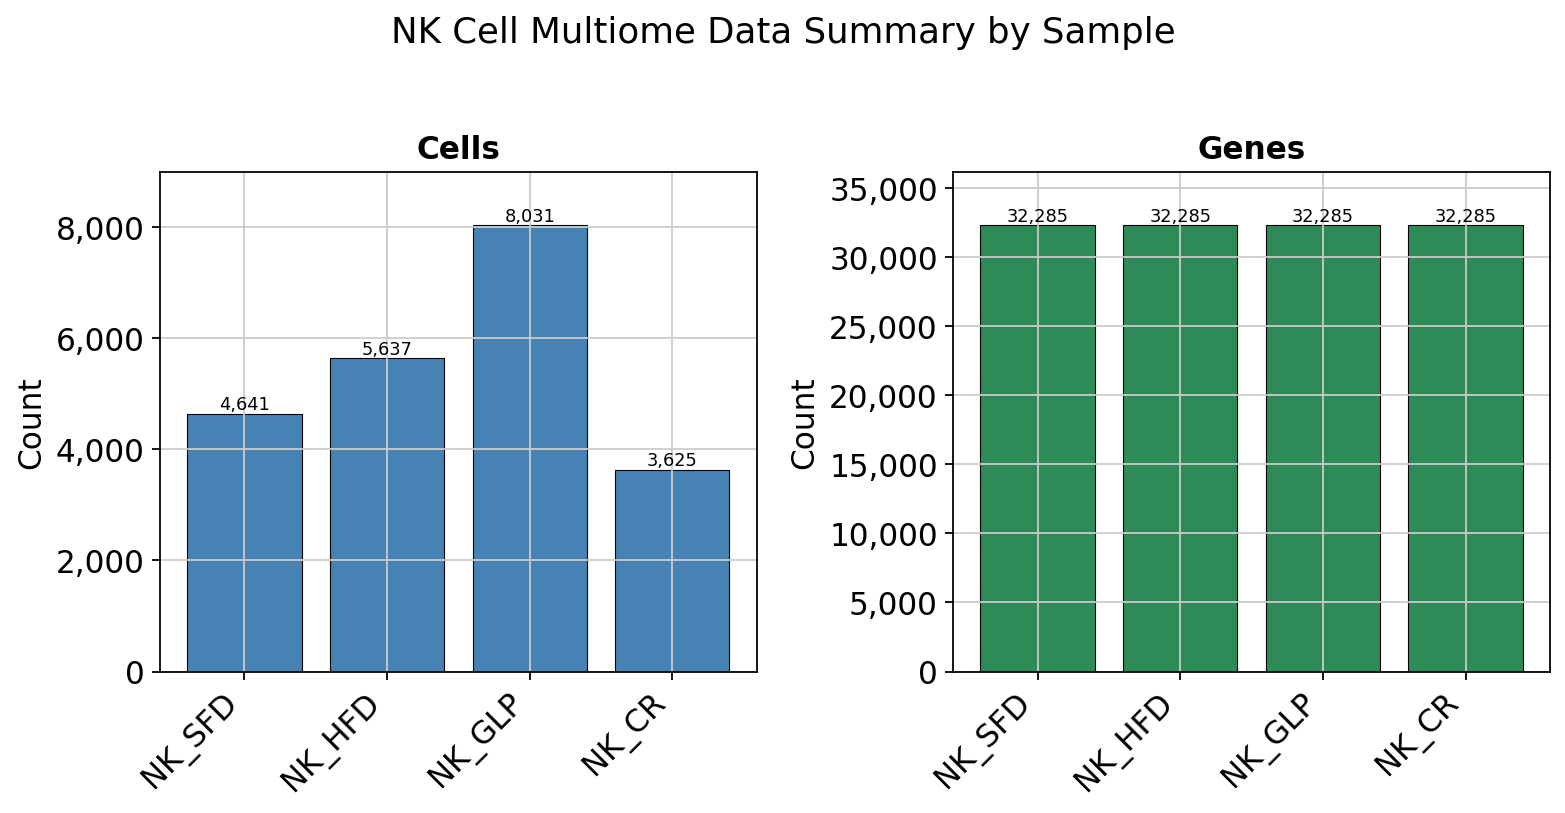

In [74]:
sample_dict = {
    'NK_SFD': nk_sfd,
    'NK_HFD': nk_hfd,
    'NK_GLP': nk_glp,
    'NK_CR':  nk_cr,
}

samples = list(sample_dict.keys())
cells, genes = [], []

for name, adata in sample_dict.items():
    gex = adata[:, adata.var['feature_types'] == 'Gene Expression']
    cells.append(adata.n_obs)
    genes.append(gex.n_vars)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
metrics = [
    ('Cells', cells, 'steelblue'),
    ('Genes', genes, 'seagreen'),
]
for ax, (title, values, color) in zip(axes, metrics):
    ax.bar(samples, values, color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticklabels(samples, rotation=45, ha='right')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))
    for i, v in enumerate(values):
        ax.text(i, v + max(values) * 0.01, f'{v:,}', ha='center', fontsize=8)
    ax.set_ylim(0, max(values) * 1.12)

plt.suptitle('NK Cell Multiome Data Summary by Sample', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/sample_summary_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [75]:
# Quality Control Functions

# Violin Plot Creation to Visualize Distributions
def qc(adata):
    adata.var['mt'] = adata.var_names.str.startswith('mt-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
    
    ax = sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], 
                      multi_panel=True, stripplot=False, show=False)
    labels = ['Genes', 'UMI Counts', 'Mitochondrial Percent']
    for a, label in zip(ax.axes.flat, labels):
        a.set_title(label)
        a.set_xlabel(label)
    plt.show()
    
# n_genes by MT % to create thresholds for low genes and mt
def qc2(adata, low_n_genes_thres, high_mt_thres):
    adata.obs["low_n_genes"]  = adata.obs["n_genes_by_counts"] <= low_n_genes_thres # flag for filtering
    adata.obs["high_mt"]      = adata.obs["pct_counts_mt"]     >= high_mt_thres # flag for filtering
    
    ct_pl_col = sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="low_n_genes", show=False)
    ct_pl_col.set_xlim(0, max(adata.obs['total_counts']))
    ct_pl_col.set_ylim(0, max(adata.obs['n_genes_by_counts']))
    ct_pl_col.axhline(low_n_genes_thres,  c="r", linestyle='--')
    plt.show()
    
    mt_ct_pl = sc.pl.scatter(adata, x="pct_counts_mt", y="n_genes_by_counts", show=False)
    mt_ct_pl.axvline(high_mt_thres,       c="r", linestyle='--')
    mt_ct_pl.axhline(low_n_genes_thres,   c="r", linestyle='--')
    plt.show()

# filter out the cells determined by the above
def qc_filter_cells(adata):
    print("Prior")
    print(adata.shape)
    adata = adata[adata.obs["low_n_genes"] == False]
    print("Post Cells with Low n Gene Filtering")
    print(adata.shape)
    adata = adata[adata.obs["high_mt"] == False]
    print("Post Cells with High MT Fraction Gene Filtering")
    print(adata.shape)
    return adata

# determine potential doublets by cutting off at a good threshold
def qc3(adata, high_ct_thres, high_n_genes_thres=None):
    adata.obs["high_counts"] = adata.obs["total_counts"] >= high_ct_thres
    if high_n_genes_thres is not None:
        adata.obs["high_n_genes_upper"] = adata.obs["n_genes_by_counts"] >= high_n_genes_thres
    else:
        adata.obs["high_n_genes_upper"] = False

    ct_pl_col = sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts",
                              color="total_counts", show=False)
    ct_pl_col.set_xlim(0, max(adata.obs['total_counts']))
    ct_pl_col.set_ylim(0, max(adata.obs['n_genes_by_counts']))
    ct_pl_col.axvline(high_ct_thres, c="r", linestyle='--', label=f'max counts={high_ct_thres:,}')
    if high_n_genes_thres is not None:
        ct_pl_col.axhline(high_n_genes_thres, c="r", linestyle='--', label=f'max genes={high_n_genes_thres:,}')
        ct_pl_col.legend(fontsize=8)
    plt.show()

# will remove cells if they have counts that are simply too high
def qc_filter_cells2(adata):
    print("Prior")
    print(adata.shape)
    adata = adata[adata.obs["high_counts"] == False]
    print("After filtering out high counts")
    print(adata.shape)
    adata = adata[adata.obs["high_n_genes_upper"] == False]
    print("After filtering out high gene counts")
    print(adata.shape)
    return adata


=== NK_SFD ===


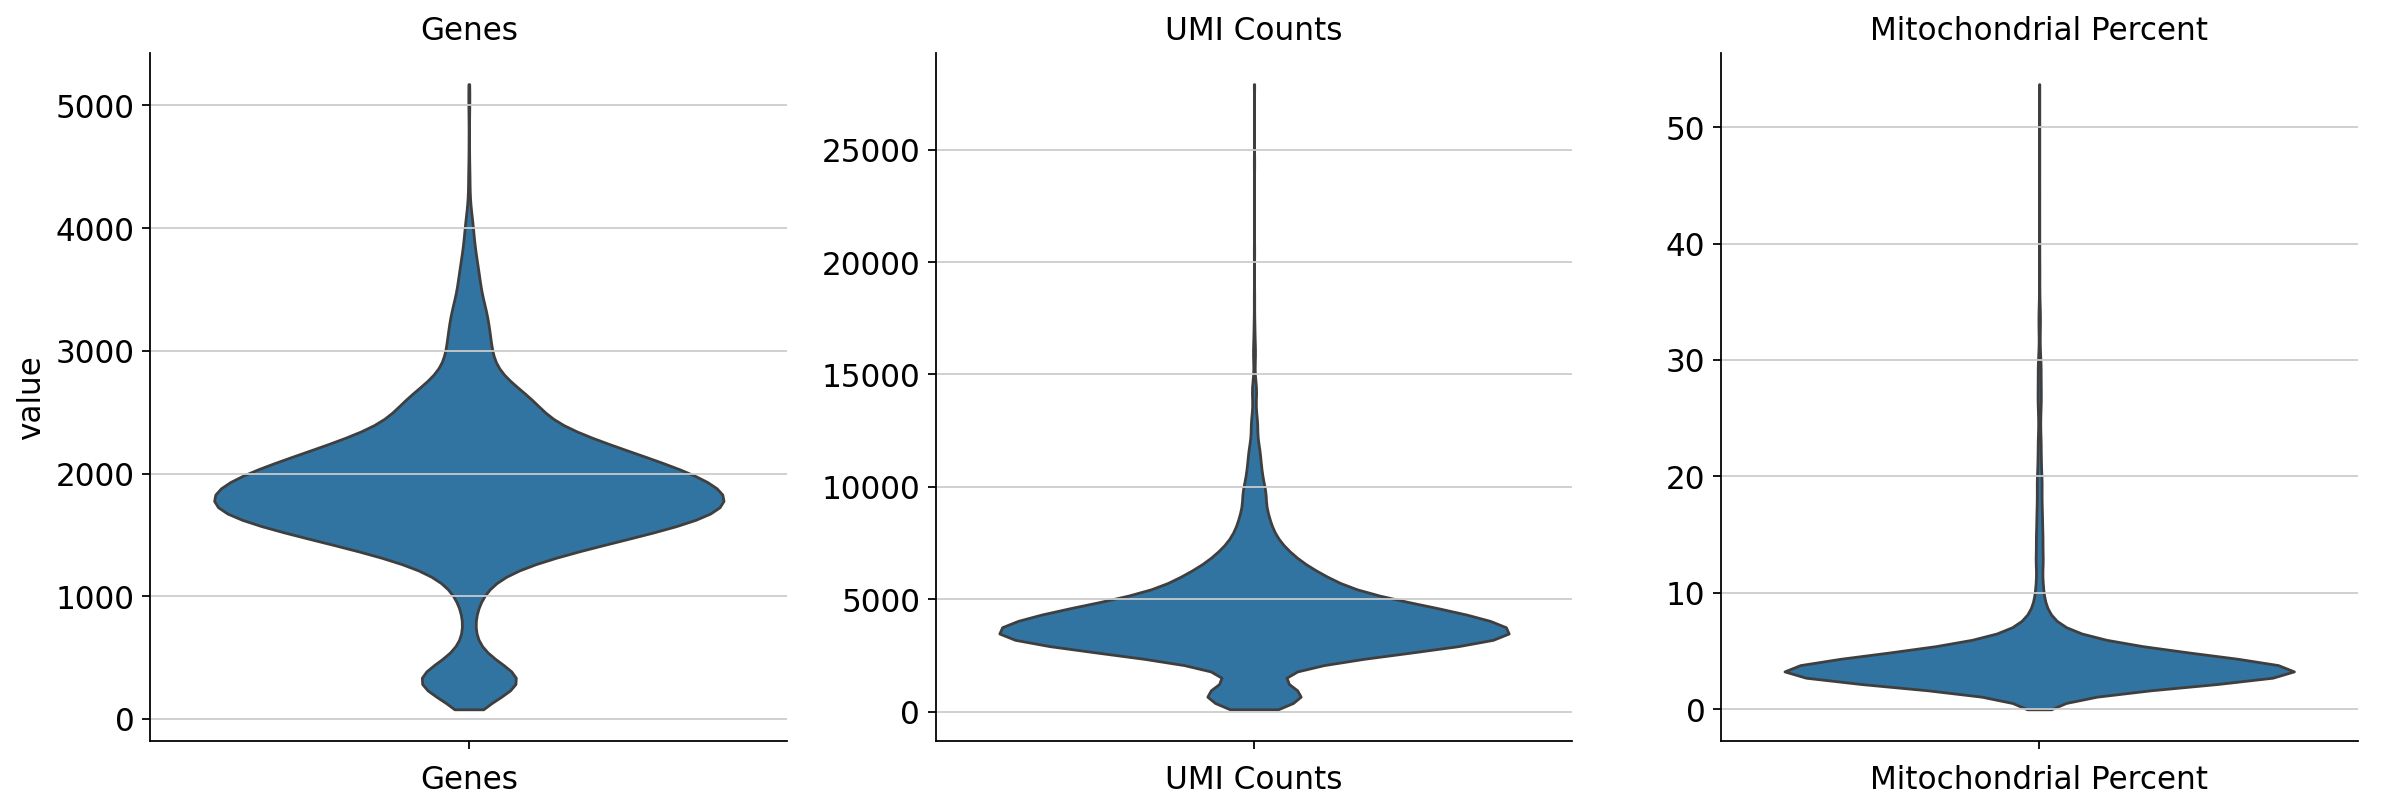


=== NK_HFD ===


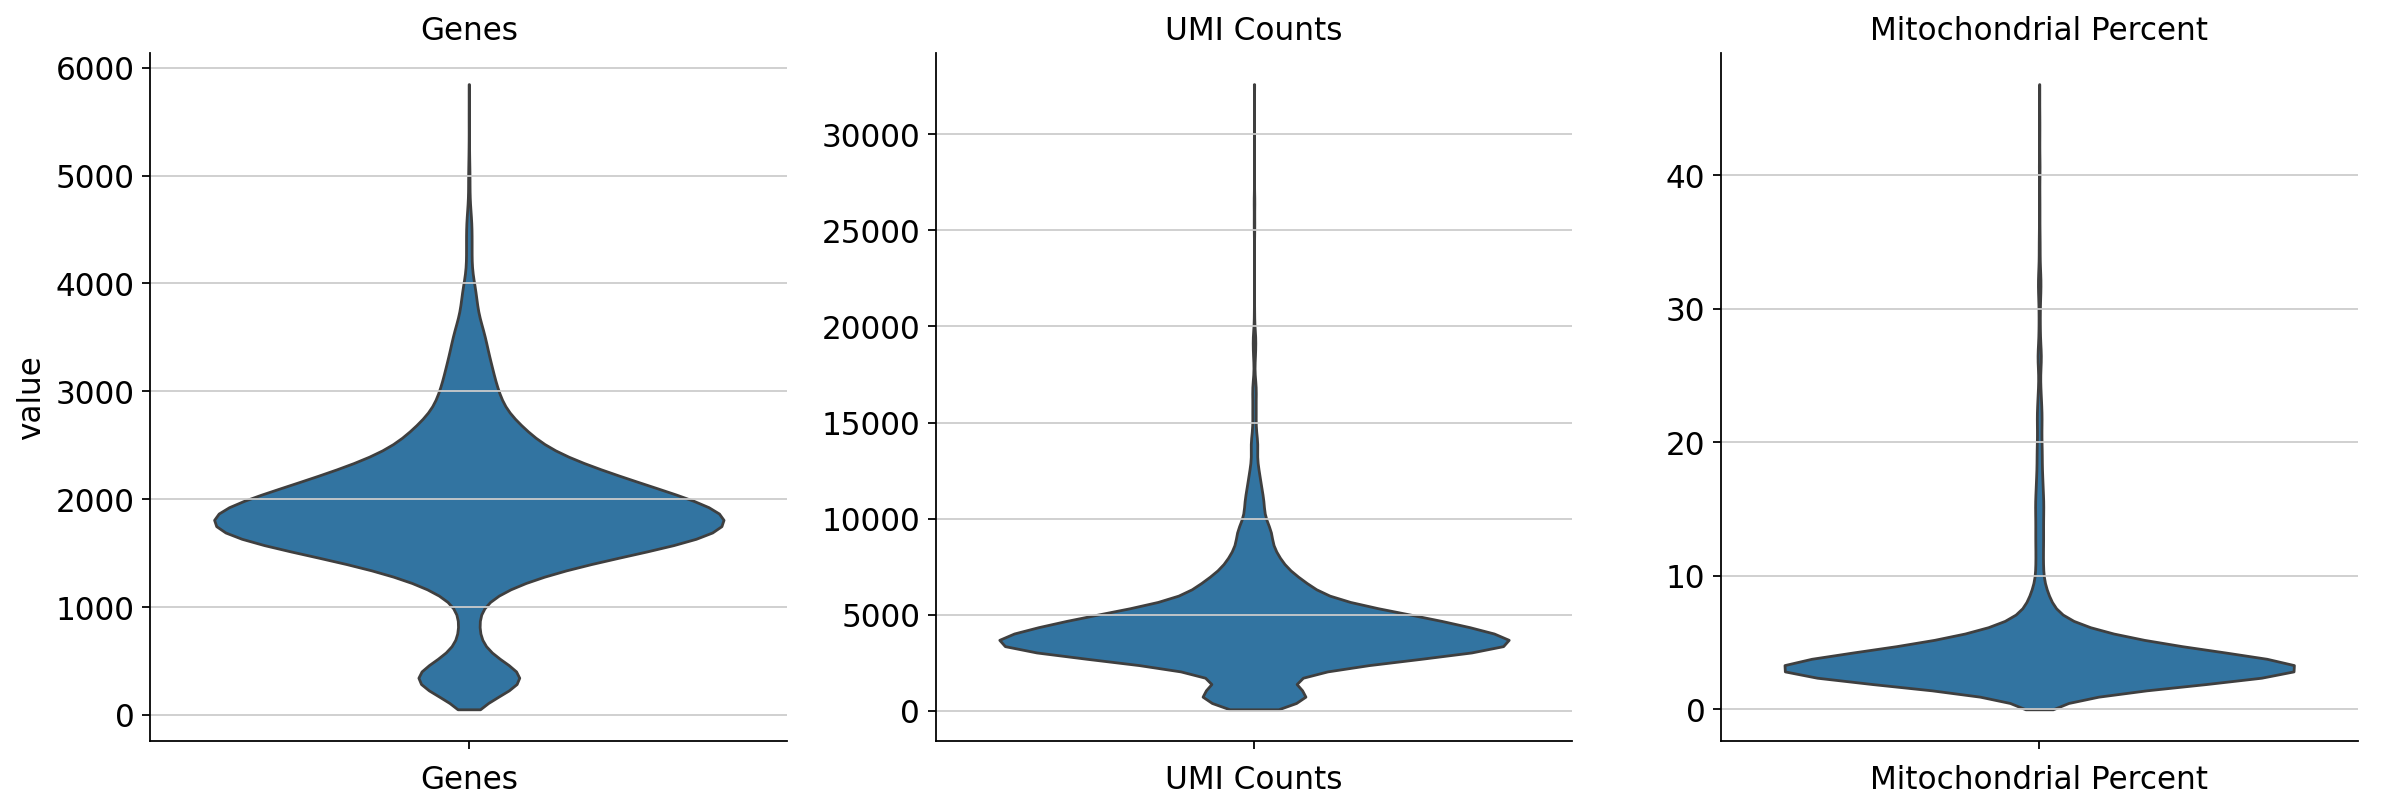


=== NK_GLP ===


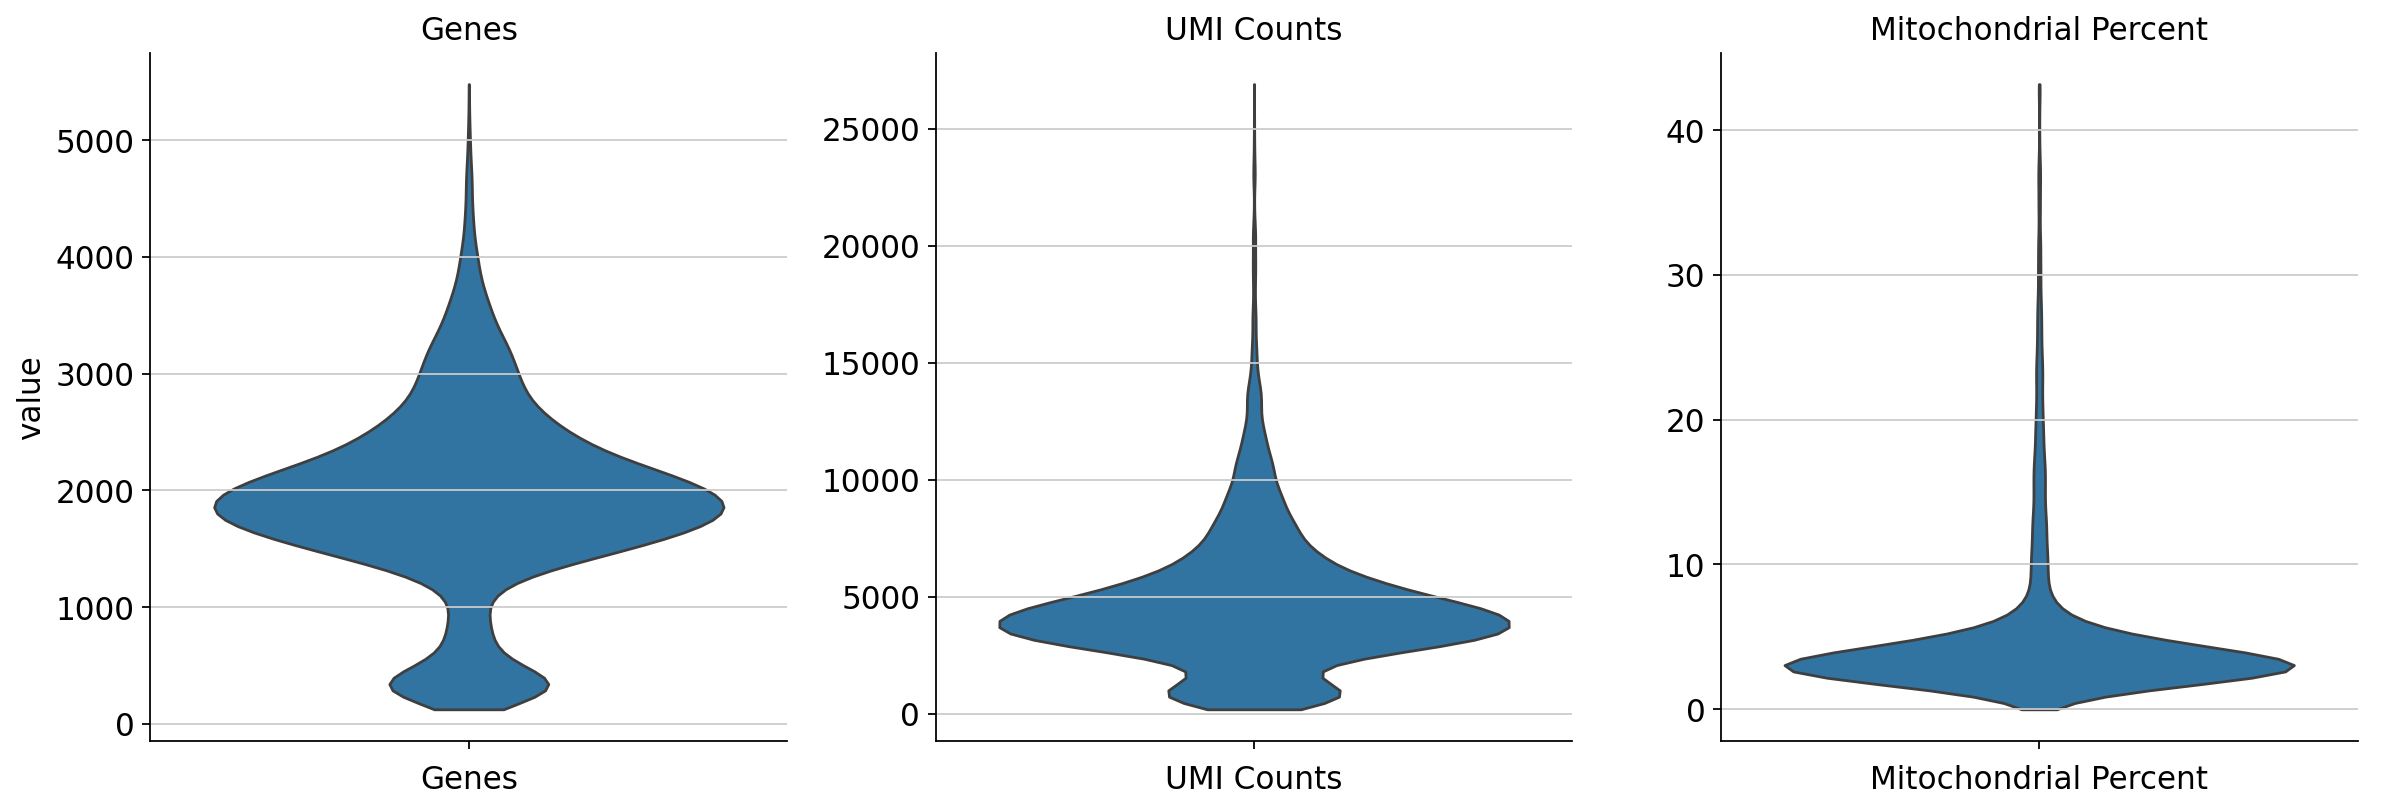


=== NK_CR ===


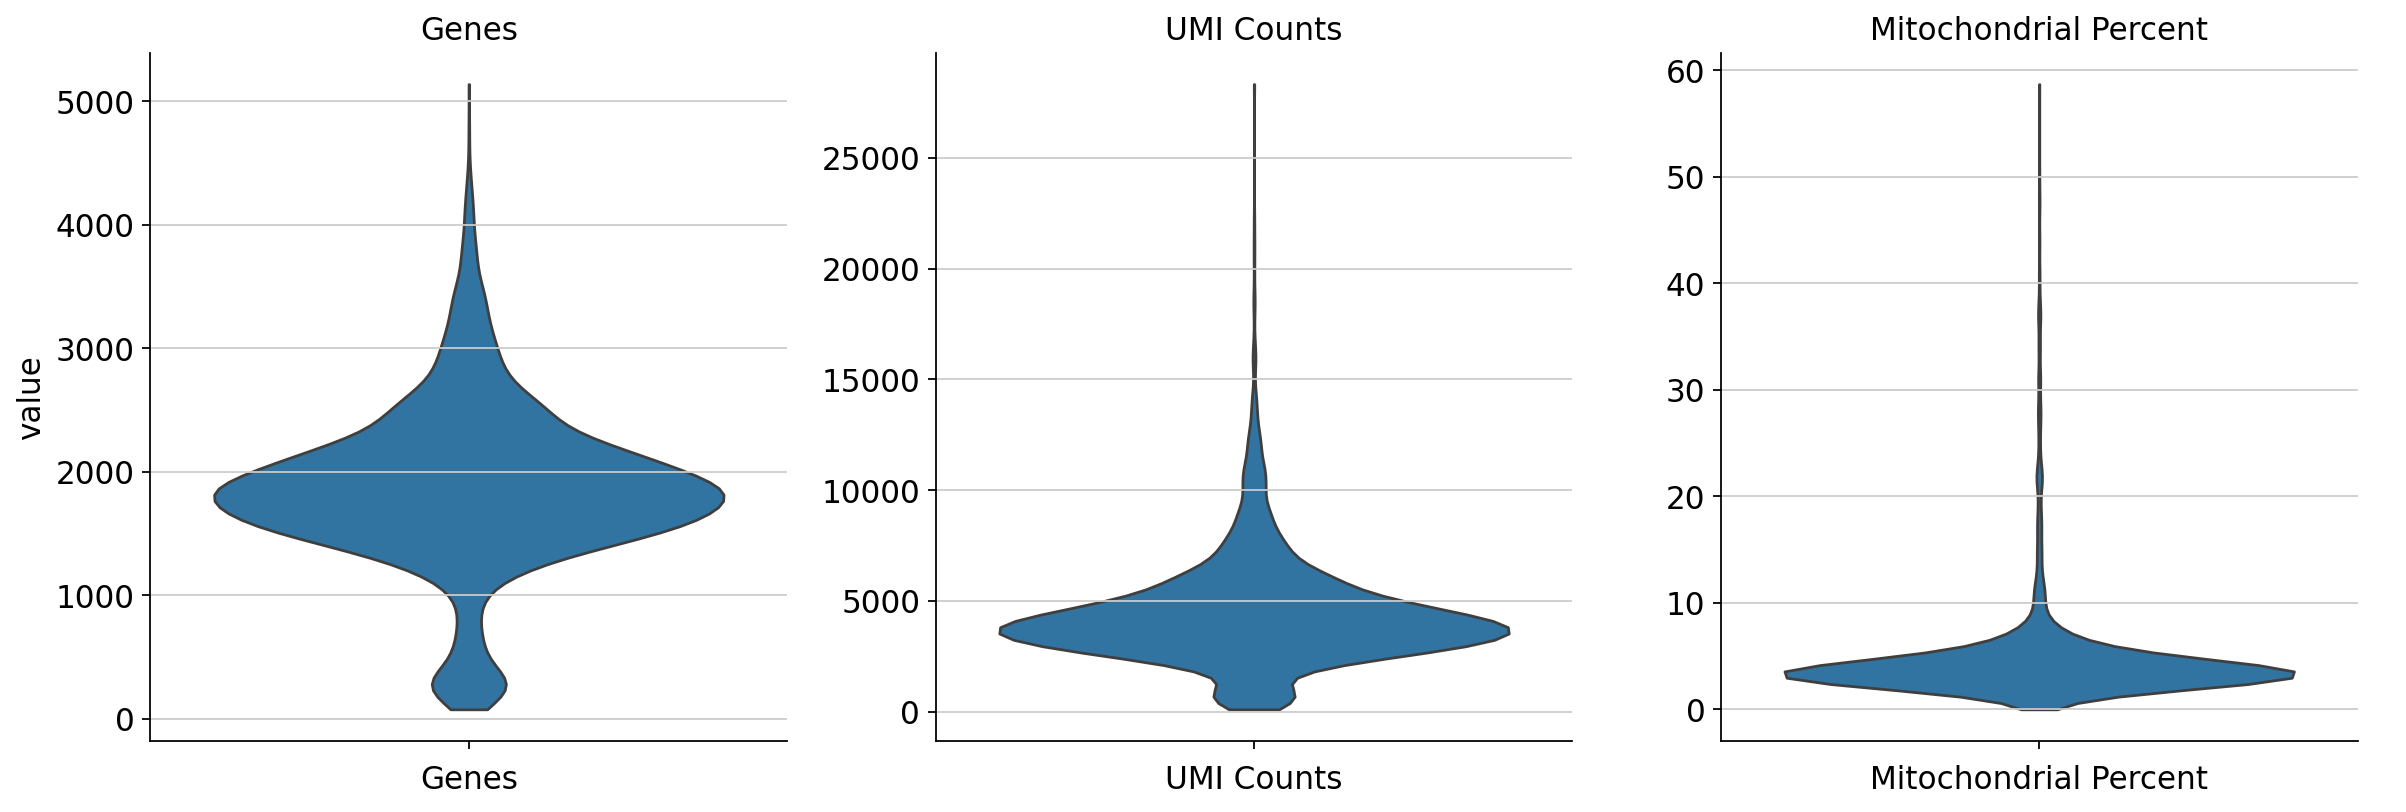

In [76]:
# Violin Plot Creation
samples_raw = {'NK_SFD': nk_sfd, 'NK_HFD': nk_hfd, 'NK_GLP': nk_glp, 'NK_CR': nk_cr}
samples_gex = {}
for name, adata in samples_raw.items():
    gex = adata[:, adata.var['feature_types'] == 'Gene Expression'].copy()
    gex.var_names_make_unique()
    samples_gex[name] = gex
    print(f"\n=== {name} ===")
    qc(gex)


=== NK_SFD ===


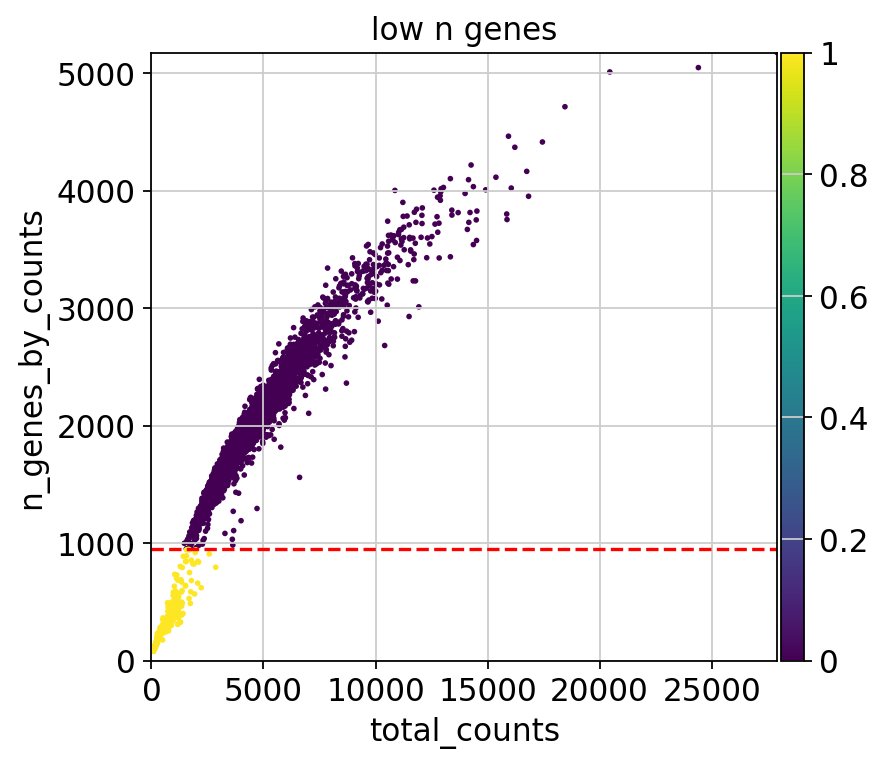

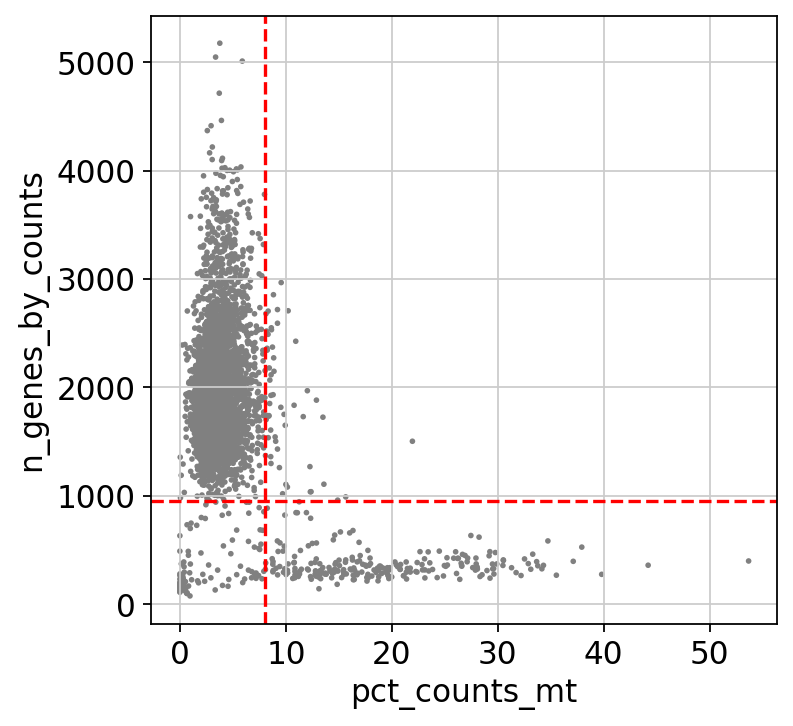


=== NK_HFD ===


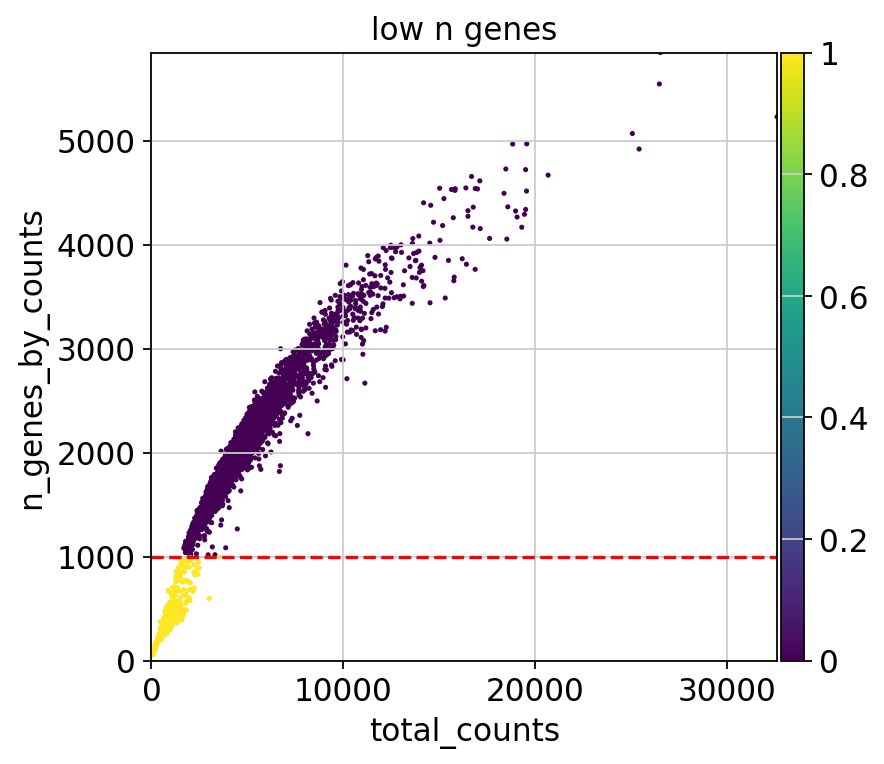

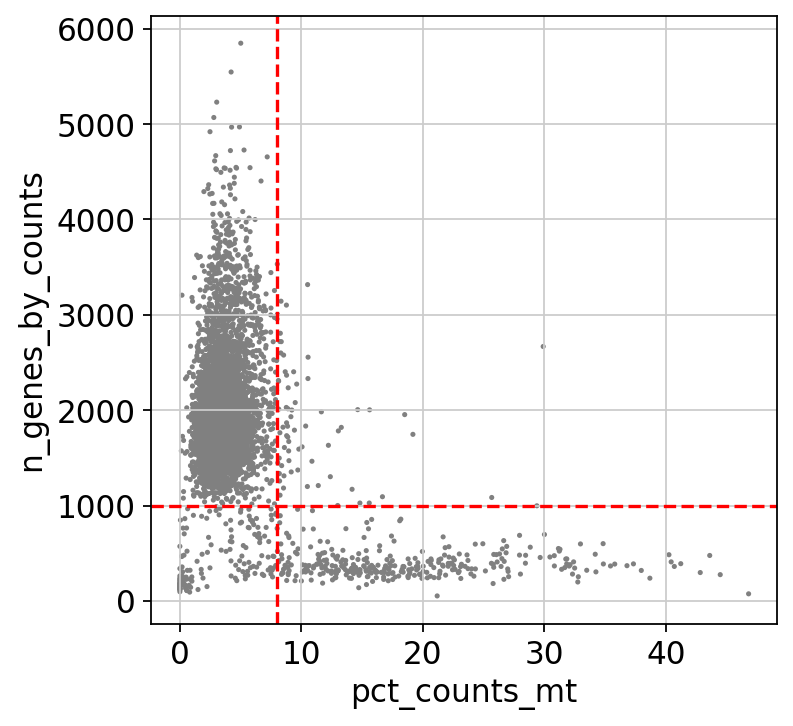


=== NK_GLP ===


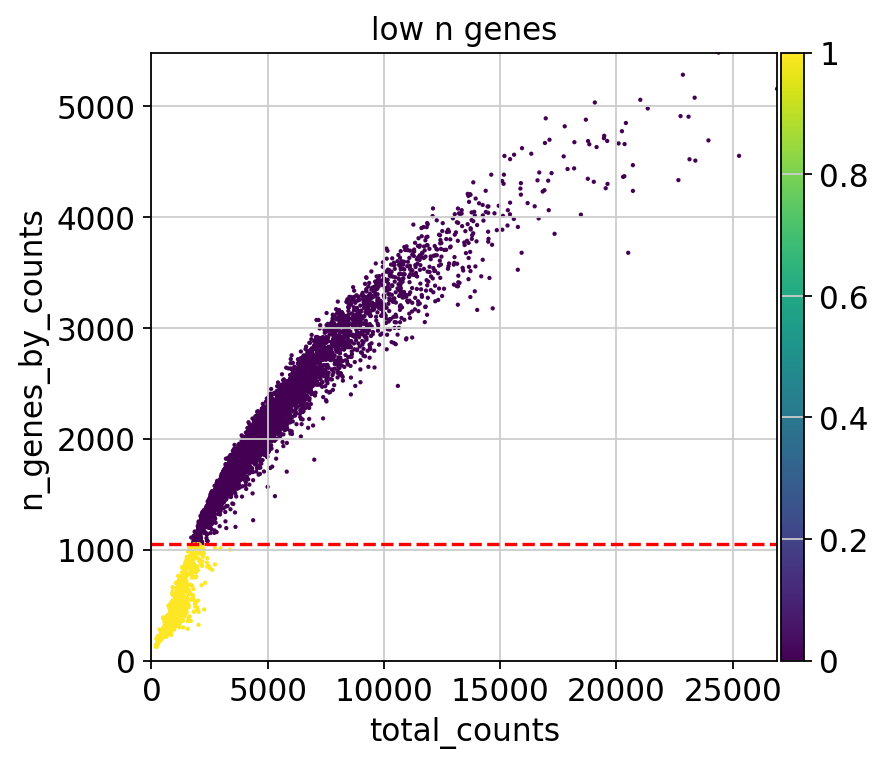

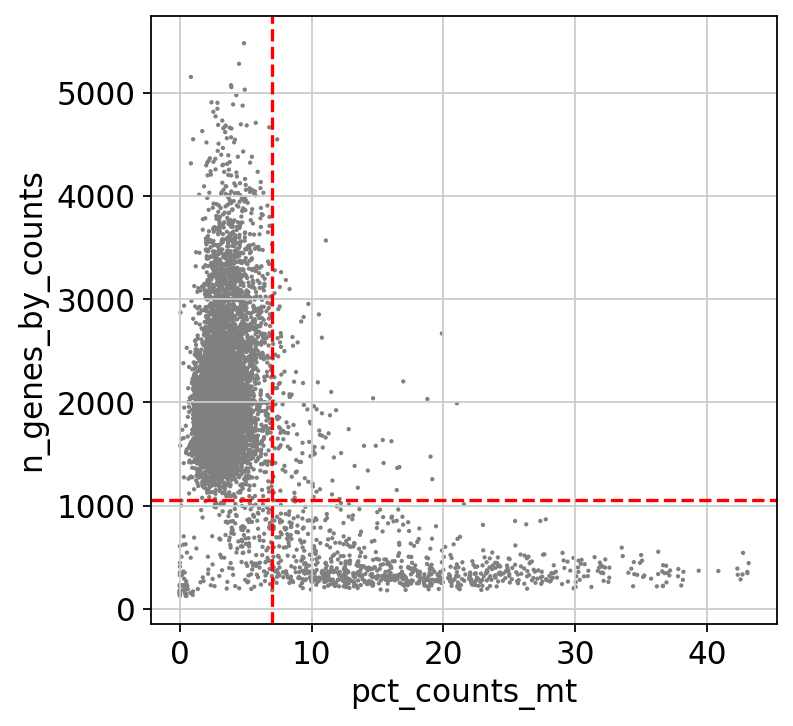


=== NK_CR ===


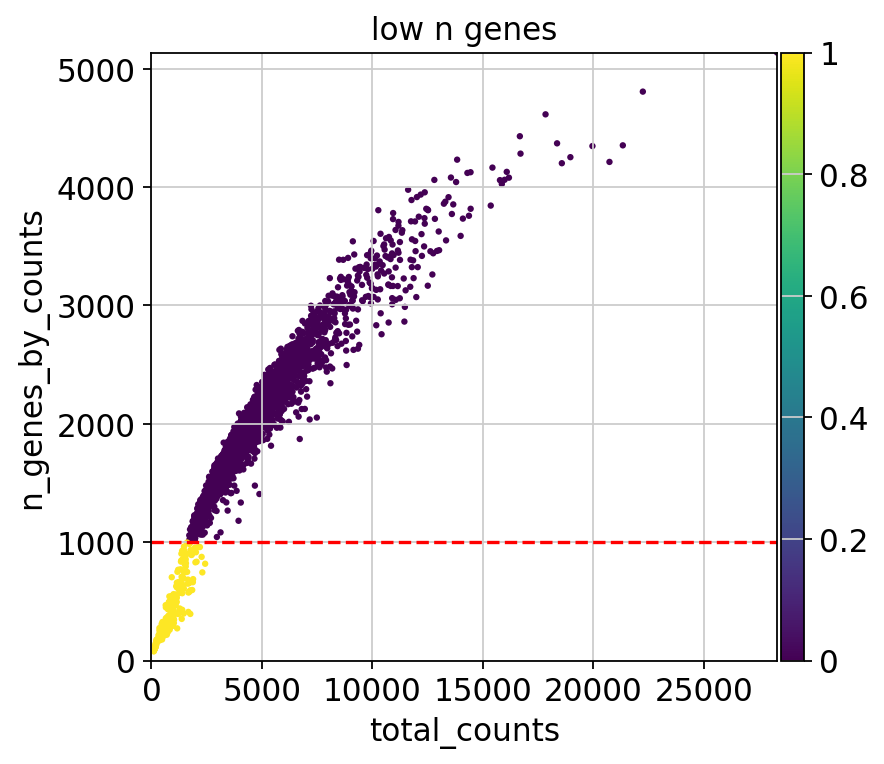

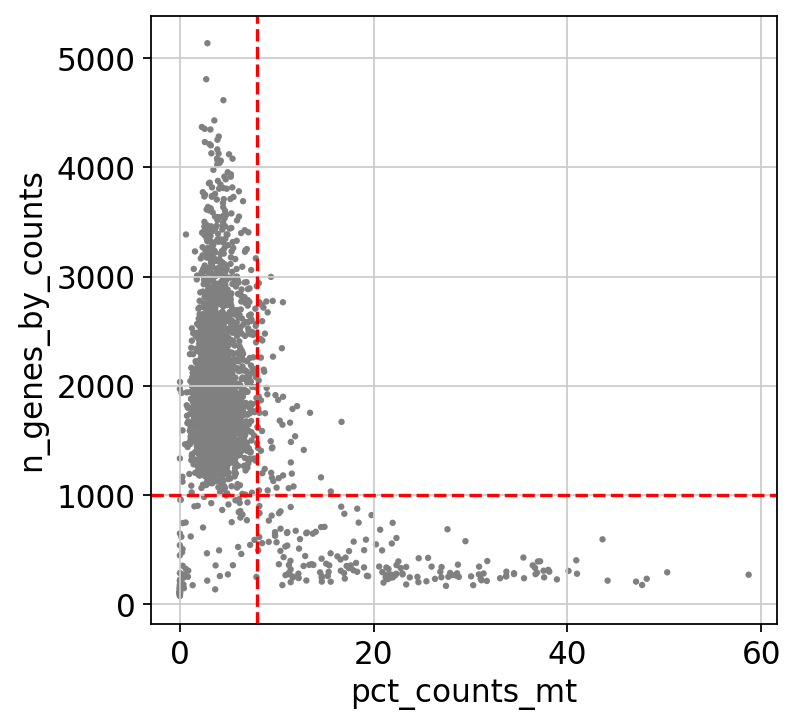

In [77]:
# Threshold Determination for 
thresholds = {
    'NK_SFD': dict(low_n_genes_thres=950, high_mt_thres=8),
    'NK_HFD': dict(low_n_genes_thres=1000, high_mt_thres=8),
    'NK_GLP': dict(low_n_genes_thres=1050, high_mt_thres=7),
    'NK_CR':  dict(low_n_genes_thres=1000, high_mt_thres=8),
}

for name, gex in samples_gex.items():
    print(f"\n=== {name} ===")
    qc2(gex, **thresholds[name])

In [78]:
samples_gex_filtered = {}
for name, gex in samples_gex.items():
    print(f"\n=== {name} ===")
    samples_gex_filtered[name] = qc_filter_cells(gex)


=== NK_SFD ===
Prior
(4641, 32285)
Post Cells with Low n Gene Filtering
(4303, 32285)
Post Cells with High MT Fraction Gene Filtering
(4247, 32285)

=== NK_HFD ===
Prior
(5637, 32285)
Post Cells with Low n Gene Filtering
(5157, 32285)
Post Cells with High MT Fraction Gene Filtering
(5089, 32285)

=== NK_GLP ===
Prior
(8031, 32285)
Post Cells with Low n Gene Filtering
(7018, 32285)
Post Cells with High MT Fraction Gene Filtering
(6871, 32285)

=== NK_CR ===
Prior
(3625, 32285)
Post Cells with Low n Gene Filtering
(3364, 32285)
Post Cells with High MT Fraction Gene Filtering
(3301, 32285)



=== NK_SFD ===


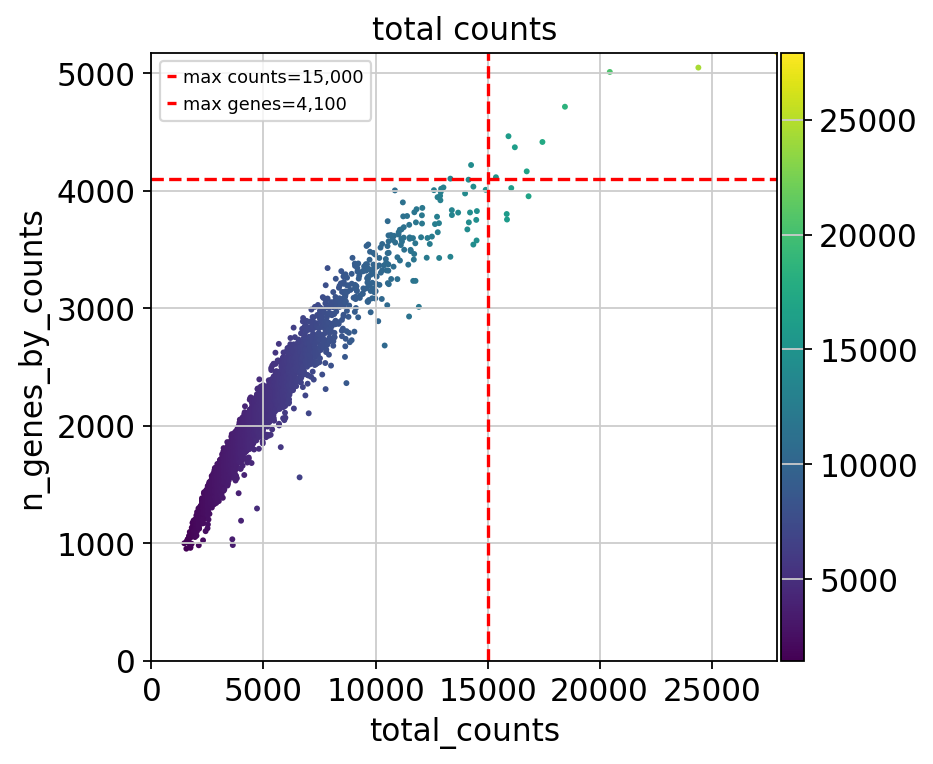


=== NK_HFD ===


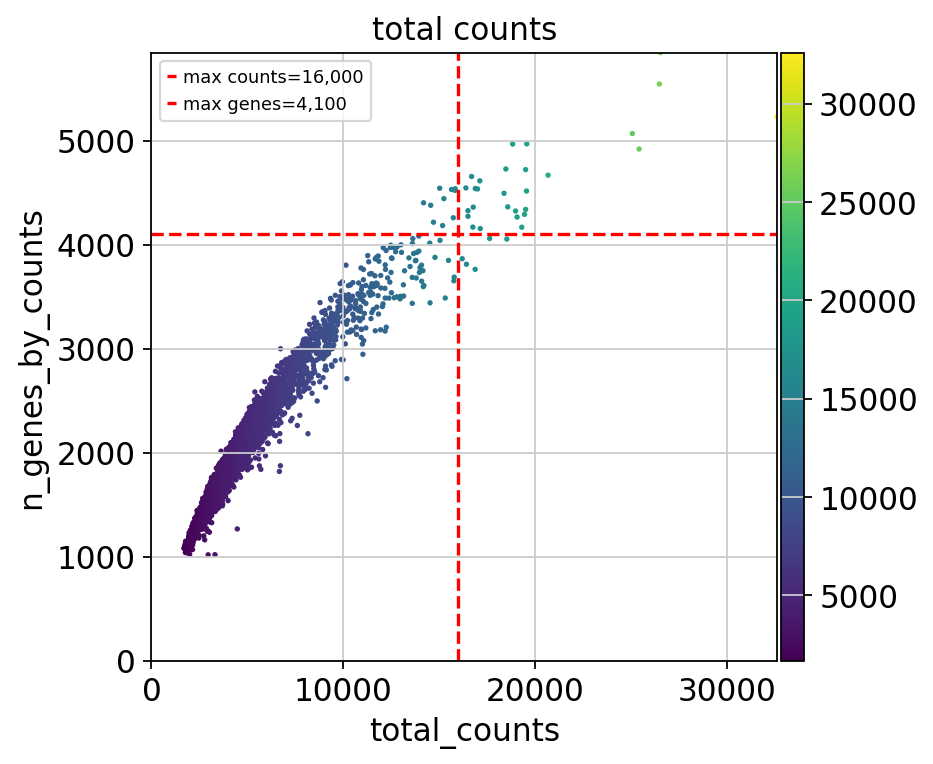


=== NK_GLP ===


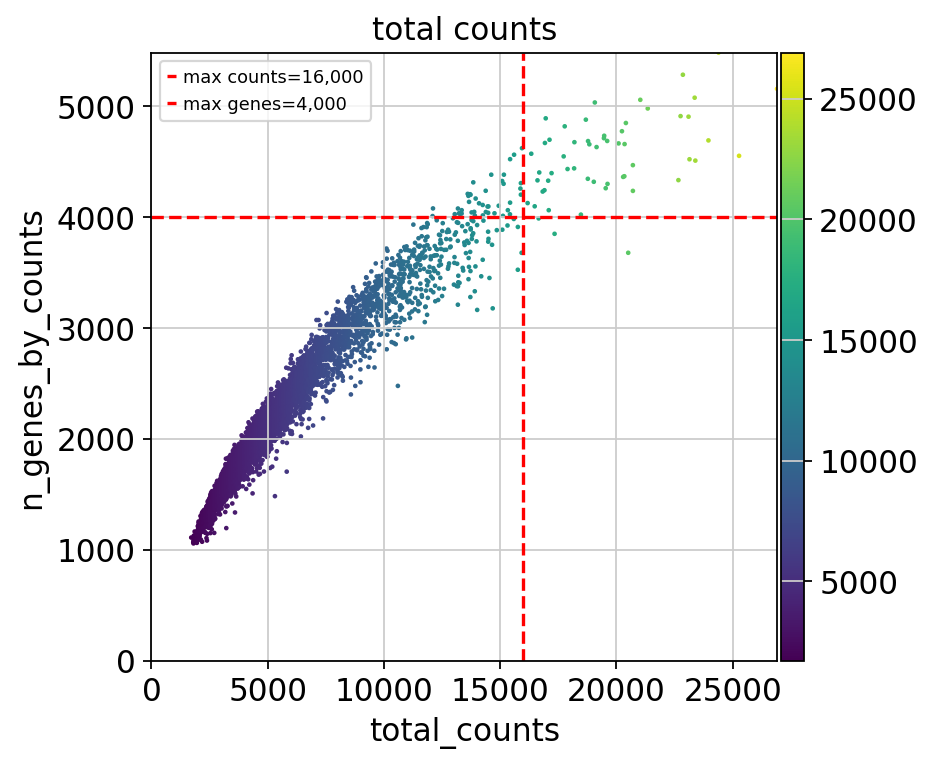


=== NK_CR ===


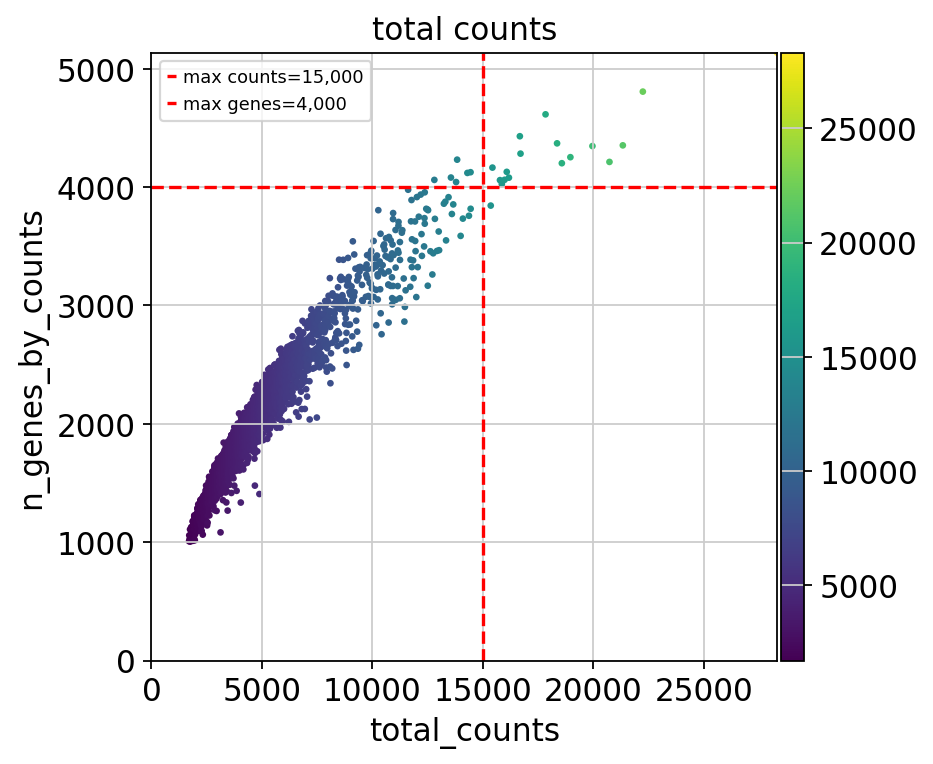

In [82]:
thresholds_ct = {
    'NK_SFD': 15000,
    'NK_HFD': 16000,
    'NK_GLP': 16000,
    'NK_CR':  15000,
}

thresholds_gene = {
    'NK_SFD': 4100,
    'NK_HFD': 4100,
    'NK_GLP': 4000,
    'NK_CR':  4000,
}

for name, gex in samples_gex_filtered.items():
    print(f"\n=== {name} ===")
    qc3(gex, high_ct_thres=thresholds_ct[name], high_n_genes_thres=thresholds_gene[name])

In [88]:
samples_gex_final = {}
for name, gex in samples_gex_filtered.items():
    print(f"\n=== {name} ===")
    samples_gex_final[name] = qc_filter_cells2(gex)


=== NK_SFD ===
Prior
(4247, 32285)
After filtering out high counts
(4234, 32285)
After filtering out high gene counts
(4232, 32285)

=== NK_HFD ===
Prior
(5089, 32285)
After filtering out high counts
(5056, 32285)
After filtering out high gene counts
(5046, 32285)

=== NK_GLP ===
Prior
(6871, 32285)
After filtering out high counts
(6816, 32285)
After filtering out high gene counts
(6774, 32285)

=== NK_CR ===
Prior
(3301, 32285)
After filtering out high counts
(3283, 32285)
After filtering out high gene counts
(3277, 32285)



=== NK_SFD ===


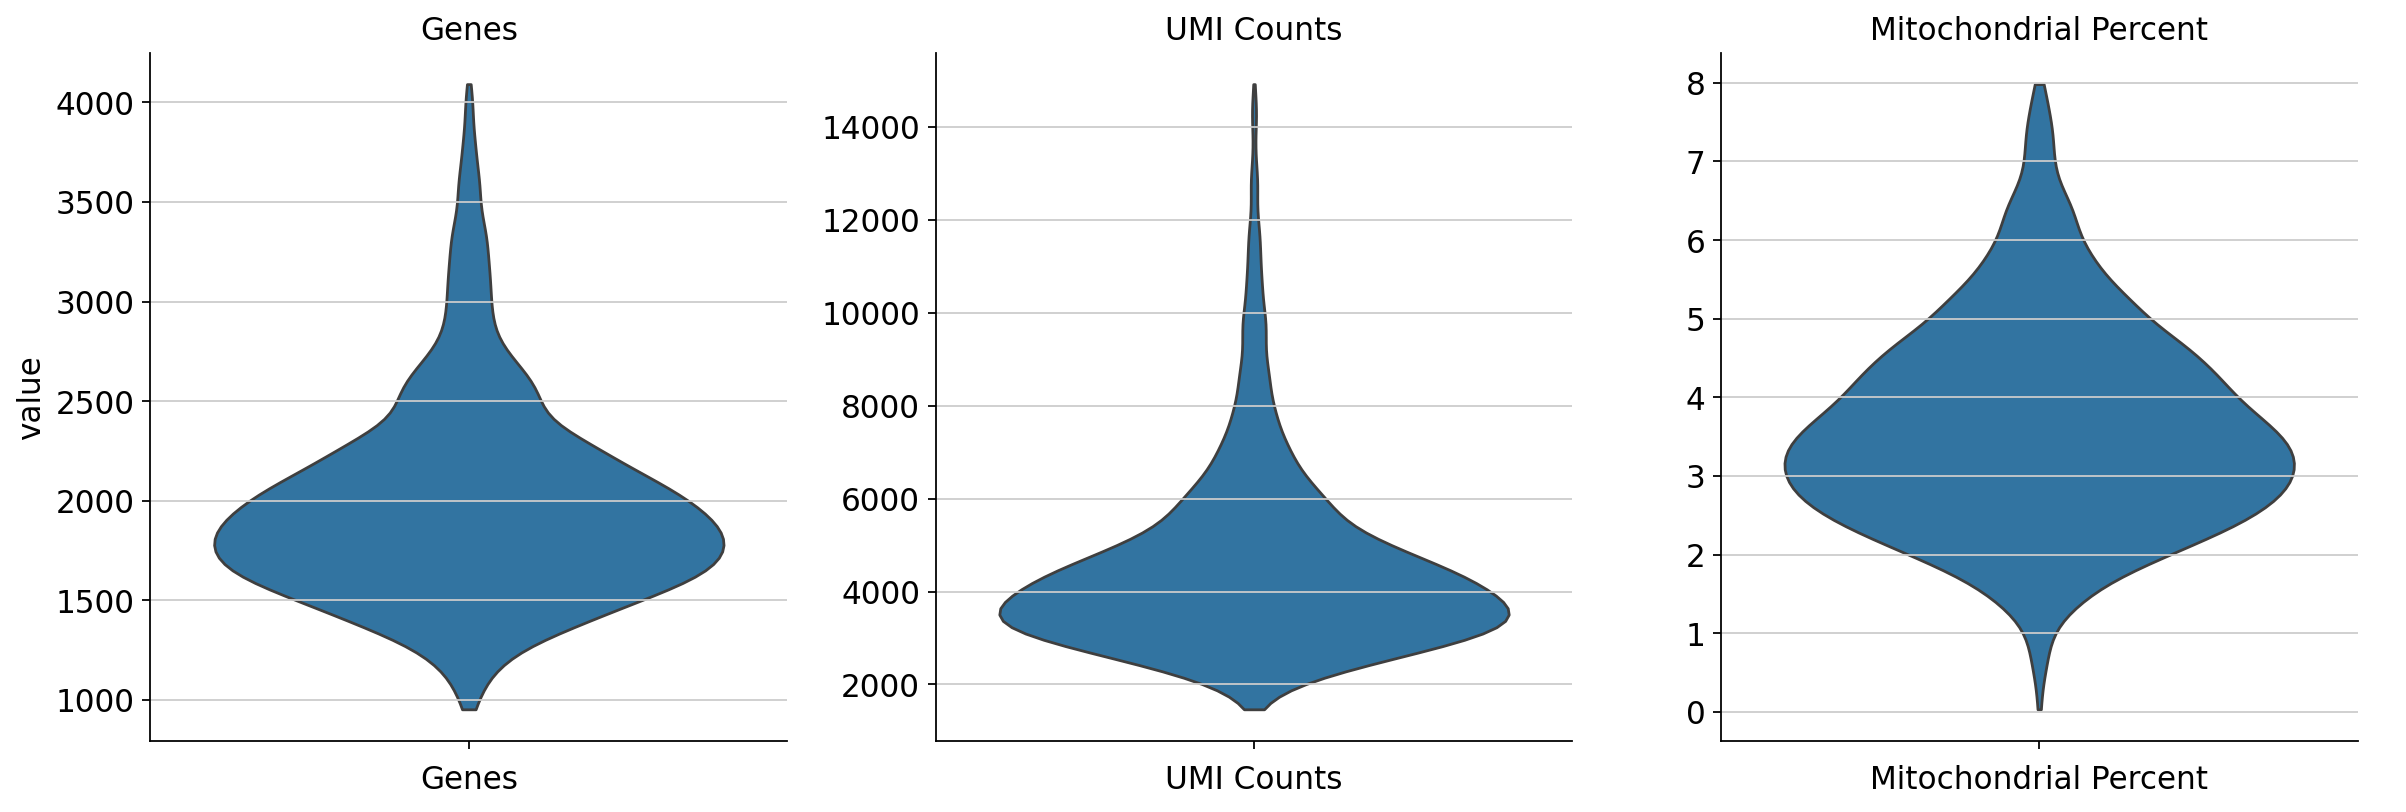


=== NK_HFD ===


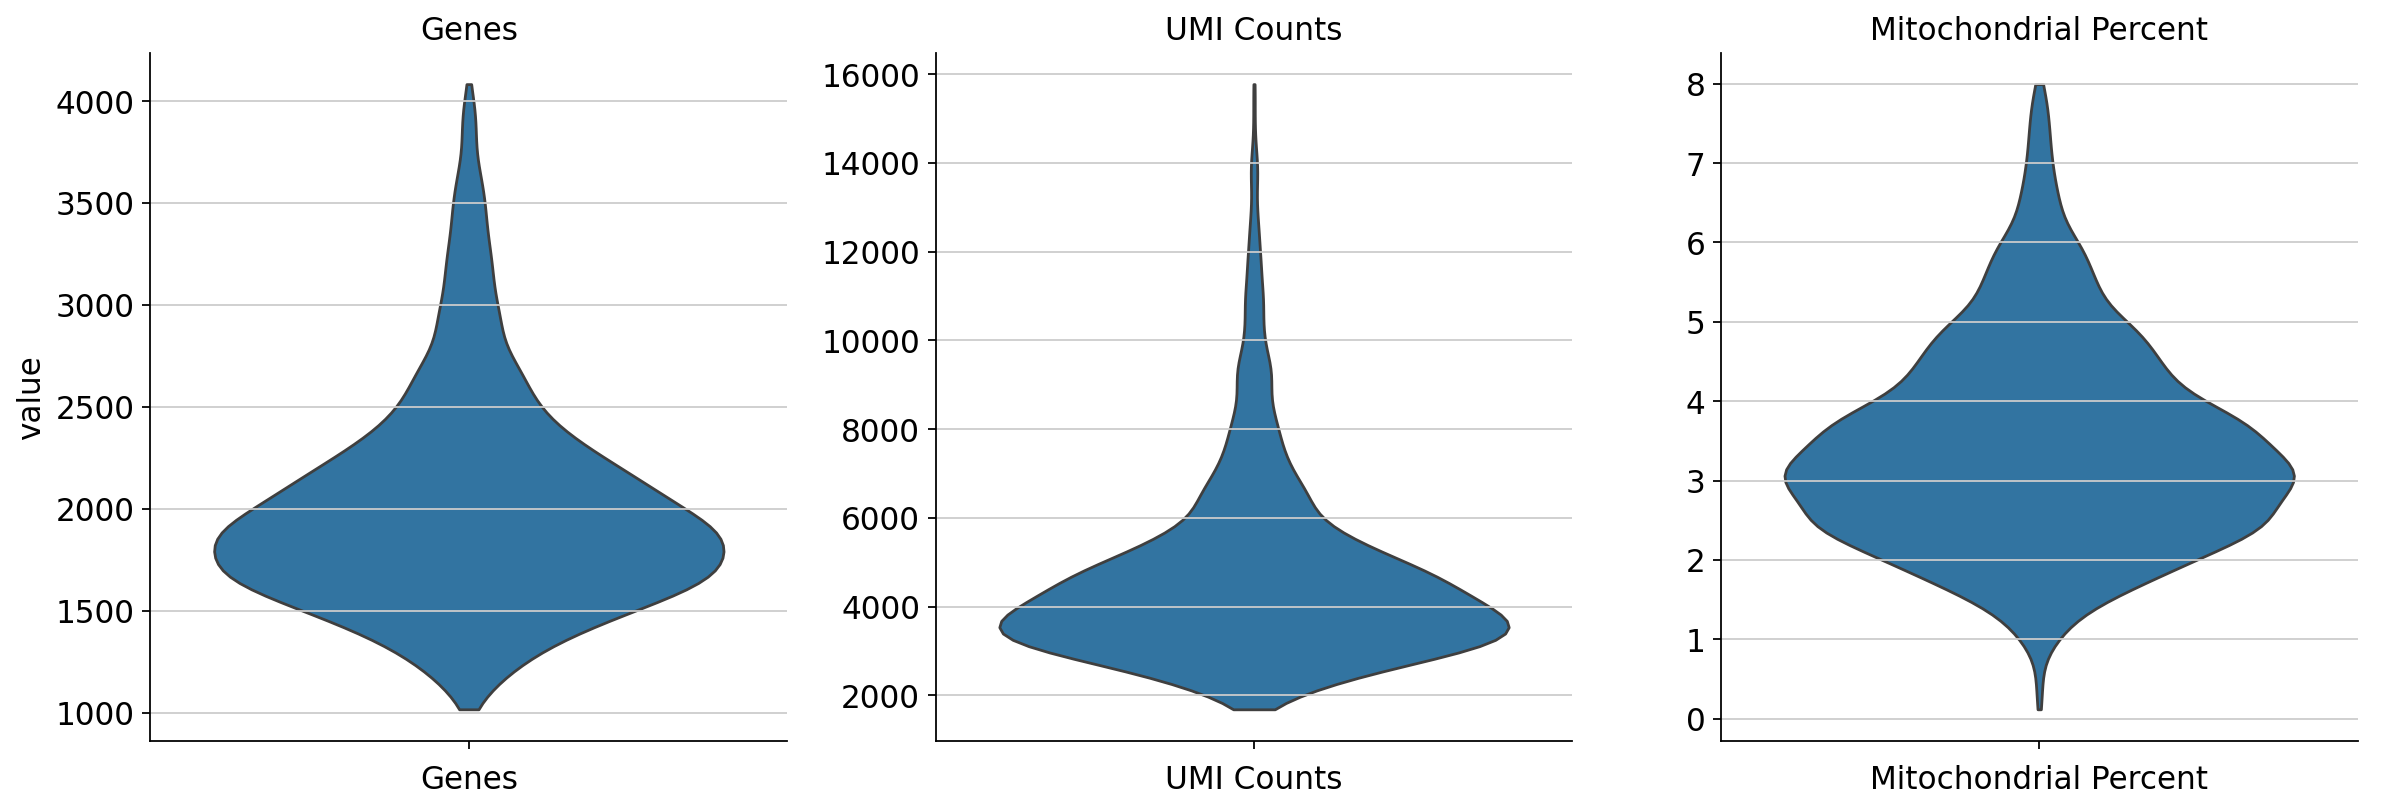


=== NK_GLP ===


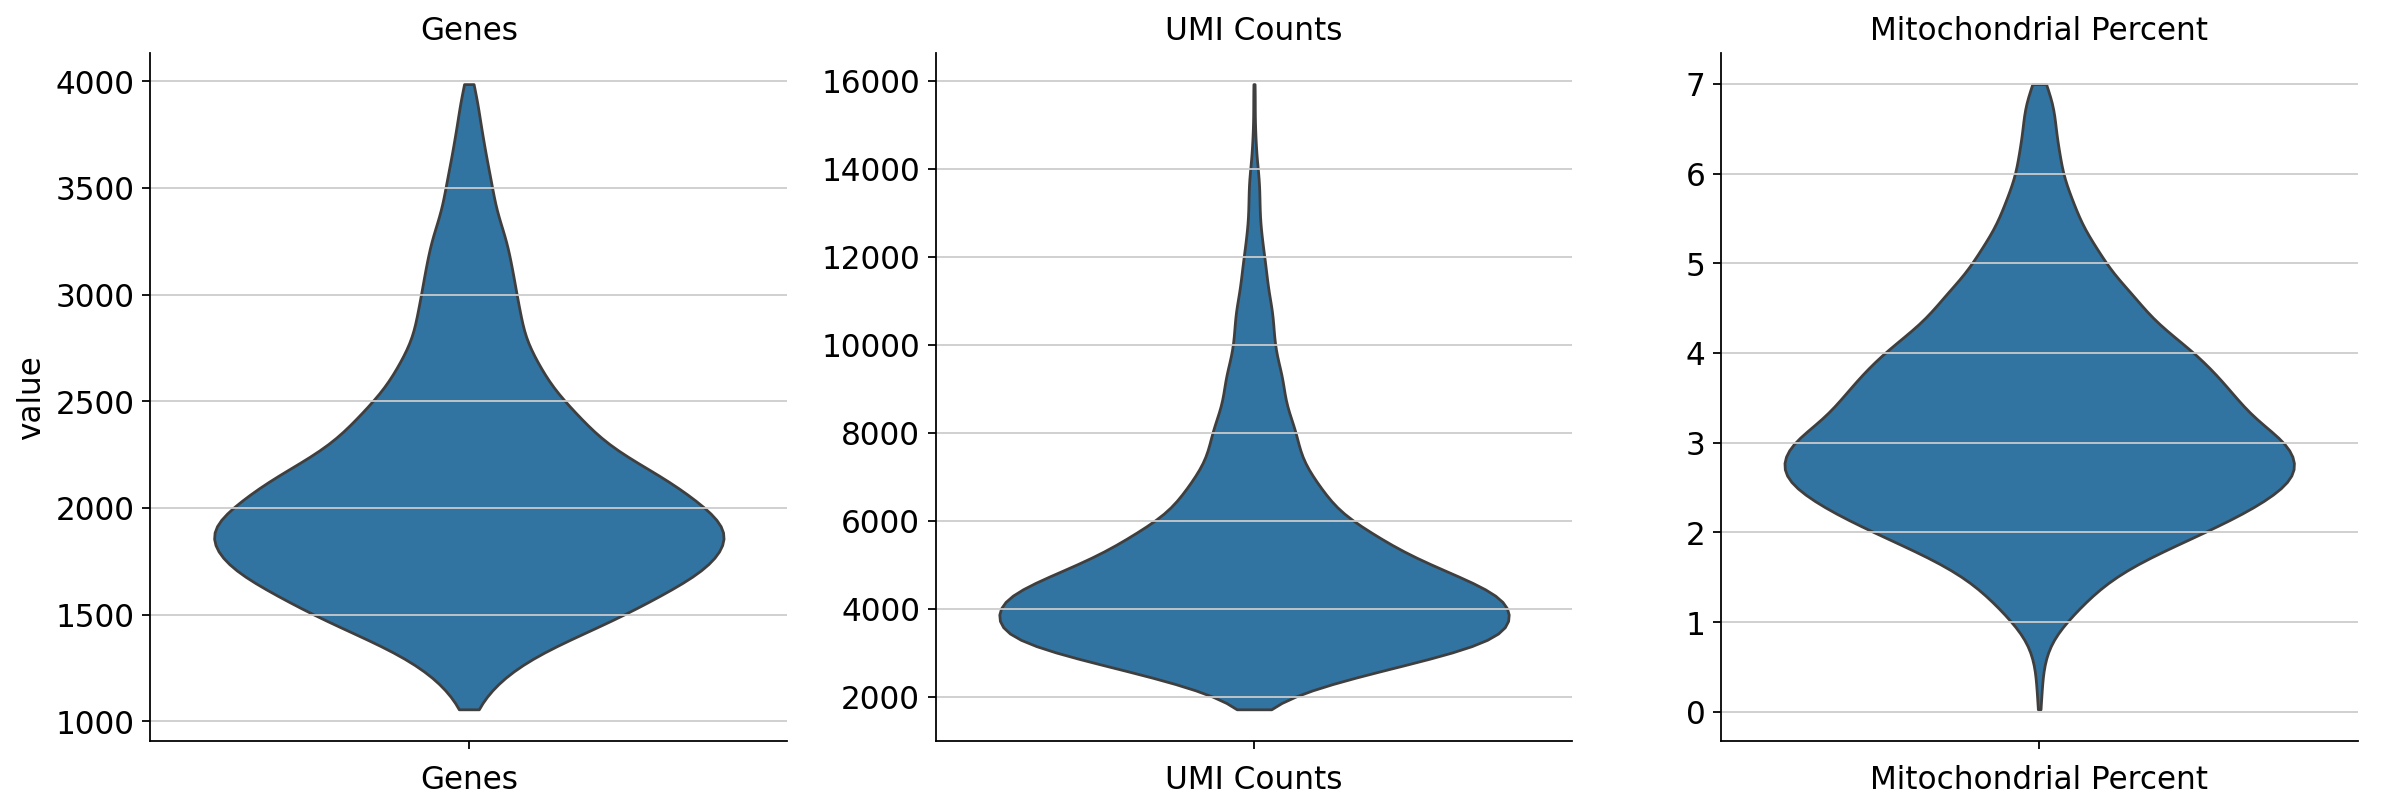


=== NK_CR ===


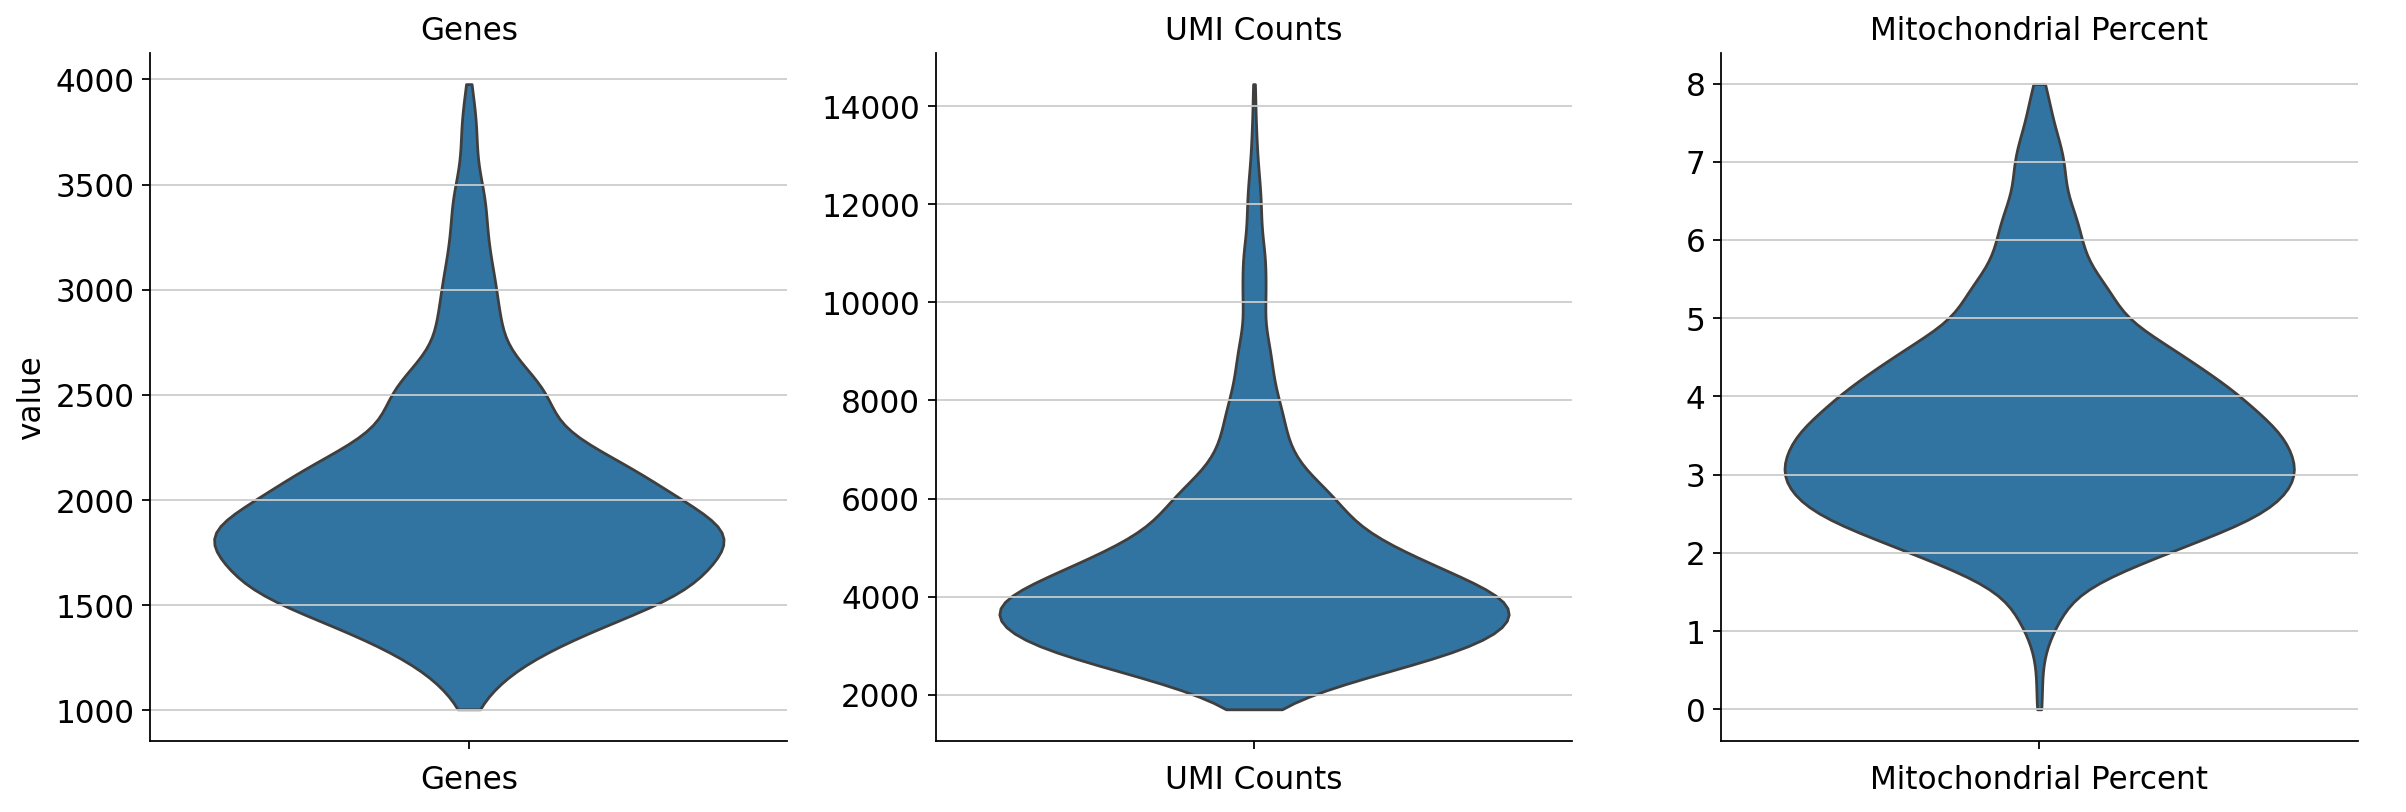

In [89]:
for name, gex in samples_gex_final.items():
    print(f"\n=== {name} ===")
    qc(gex)

Condition                         NK_CR  NK_GLP  NK_HFD  NK_SFD
Stage                                                          
After High Count / Gene Filter     3277    6774    5046    4232
After Low Gene / High MT Filter    3301    6871    5089    4247
Raw (Cell Ranger Count, Initial)   3625    8031    5637    4641


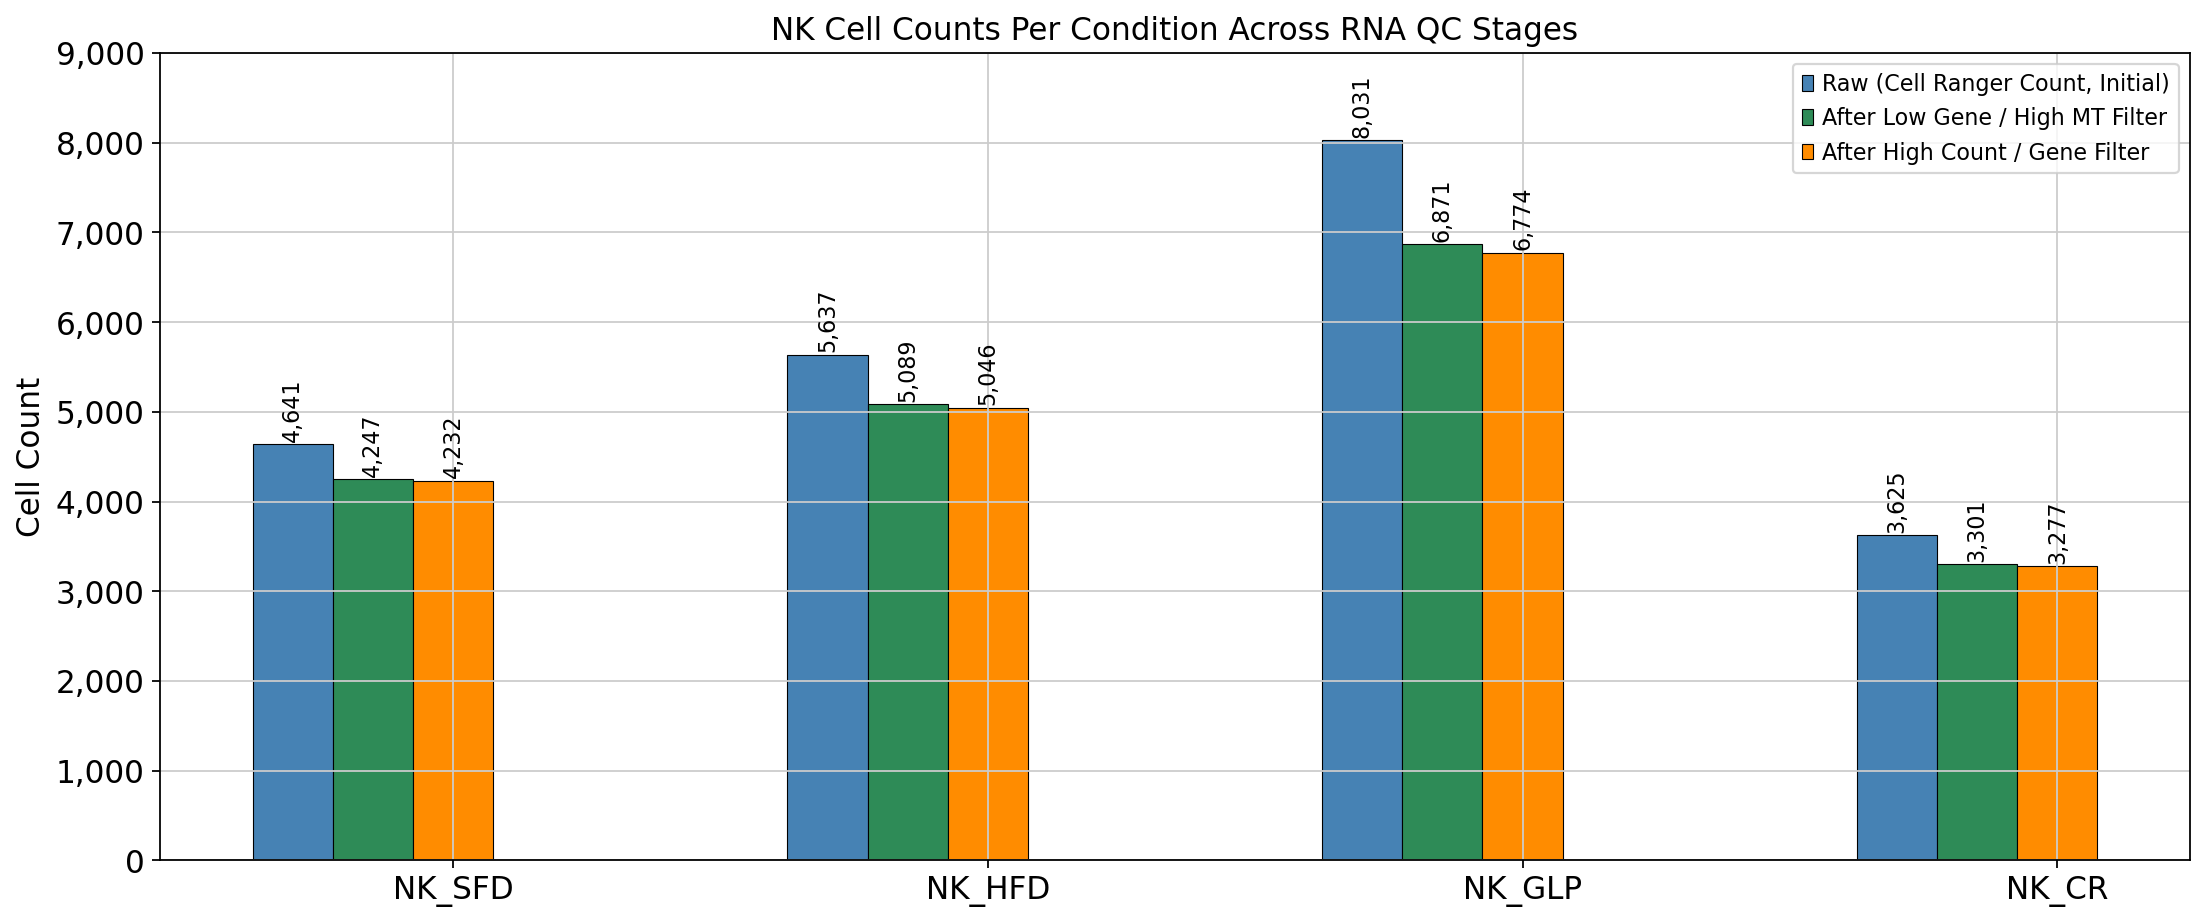

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Cell counts at each QC stage ─────────────────────────────────────────────

stages = {
    'Raw (Cell Ranger Count, Initial)'              : samples_raw,
    'After Low Gene / High MT Filter': samples_gex_filtered,
    'After High Count / Gene Filter'        : samples_gex_final,
}

conditions = ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']

# Build summary dataframe
records = []
for stage, sample_dict in stages.items():
    for name in conditions:
        adata = sample_dict[name]
        records.append({'Stage': stage, 'Condition': name, 'Cells': adata.n_obs})

df = pd.DataFrame(records)
print(df.pivot(index='Stage', columns='Condition', values='Cells').to_string())

# ── Bar plot ──────────────────────────────────────────────────────────────────

stage_labels = list(stages.keys())
x = np.arange(len(conditions))
width = 0.15
colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (stage, color) in enumerate(zip(stage_labels, colors)):
    counts = [df[(df['Stage'] == stage) & (df['Condition'] == c)]['Cells'].values[0] for c in conditions]
    bars = ax.bar(x + i * width, counts, width, label=stage, color=color, edgecolor='black', linewidth=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{count:,}', ha='center', va='bottom', fontsize=10, rotation=90)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(conditions)
ax.set_ylabel('Cell Count')
ax.set_ylim(0, 9000)
ax.set_title('NK Cell Counts Per Condition Across RNA QC Stages')
ax.legend(loc='upper right', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))

plt.tight_layout()
plt.savefig('/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/cell_counts_per_qc_stage.png', dpi=150, bbox_inches='tight')
plt.show()

In [91]:
import os

out_dir = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/'

for name, gex in samples_gex_final.items():
    out_path = os.path.join(out_dir, f'{name}_gex_filtered.h5ad')
    gex.write_h5ad(out_path)
    print(f"Saved {name} → {out_path}")

Saved NK_SFD → /Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/NK_SFD_gex_filtered.h5ad
Saved NK_HFD → /Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/NK_HFD_gex_filtered.h5ad
Saved NK_GLP → /Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/NK_GLP_gex_filtered.h5ad
Saved NK_CR → /Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/NK_CR_gex_filtered.h5ad


In [92]:
import os

barcode_dir = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/barcodes'
os.makedirs(barcode_dir, exist_ok=True)

for name, gex in samples_gex_final.items():
    out_path = f'{barcode_dir}/{name}_barcodes.txt'
    with open(out_path, 'w') as f:
        for bc in gex.obs_names:
            f.write(f'{bc}\n')
    print(f"{name}: {gex.n_obs:,} barcodes saved → {out_path}")

NK_SFD: 4,232 barcodes saved → /Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/barcodes/NK_SFD_barcodes.txt
NK_HFD: 5,046 barcodes saved → /Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/barcodes/NK_HFD_barcodes.txt
NK_GLP: 6,774 barcodes saved → /Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/barcodes/NK_GLP_barcodes.txt
NK_CR: 3,277 barcodes saved → /Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/barcodes/NK_CR_barcodes.txt


In [93]:
# quick check
barcode_dir = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/barcodes'
with open(f'{barcode_dir}/NK_SFD_barcodes.txt') as f:
    print(f.readlines()[:5])

['AAACAGCCACCTAAGC-1\n', 'AAACAGCCAGATTCAT-1\n', 'AAACATGCAAGGCCAA-1\n', 'AAACATGCACAACAAA-1\n', 'AAACCGAAGCTCATAA-1\n']
